# Análisis de Porcentaje y Correlación de Colores
Este notebook genera gráficos de barras para el porcentaje de colores y diagramas de dispersión para la correlación entre idiomas (Inglés, Español y Tsimane), basado en el archivo `munsell-array-fixed-choice.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar estilo de los gráficos
sns.set_theme(style="whitegrid")

# Cargar datos
df = pd.read_csv('munsell-array-fixed-choice.csv')
df.head()

,grid,x,y,munsell_code,tile_hex,english_color,spanish_color,tsimane_color,spanish,tsimane
0,B1,1,7,5R8/6,#fbb6b0,pink,pink,yellow,rosada (pink),chamus (yellow)
1,D1,1,5,5R6/12,#eb6a68,pink,pink,red,rosada (pink),jainas (red)
2,F1,1,3,5R4/14,#bb1933,red,red,red,rojo (red),jainas (red)
3,H1,1,1,5R2/8,#610d25,red,red,brown,rojo (red),cafedyeisi (brown)
4,A2,2,8,10R9/2,#f2ded8,pink,white,white,blanco (white),jaibas (white)


## 1. Porcentaje de Colores por Idioma

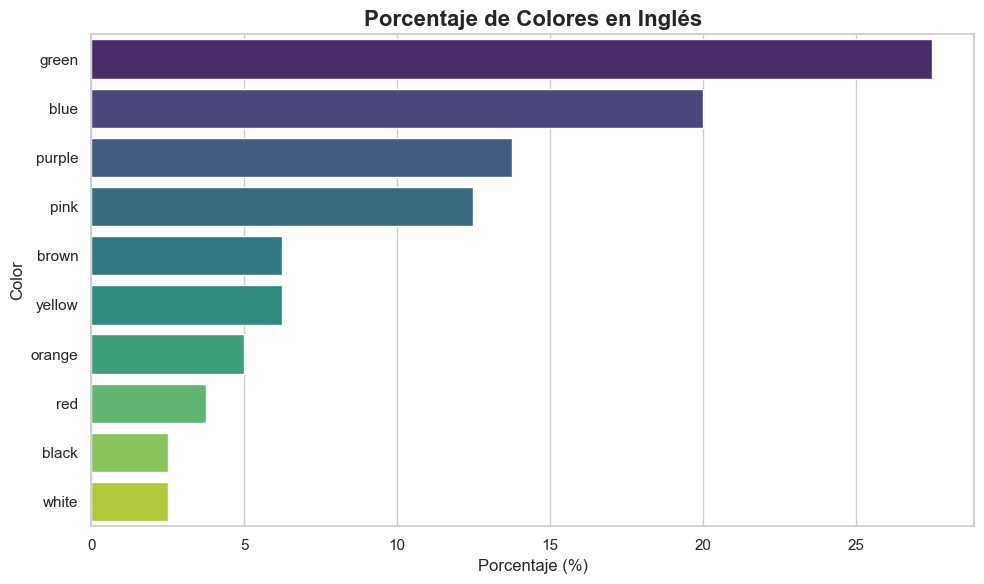

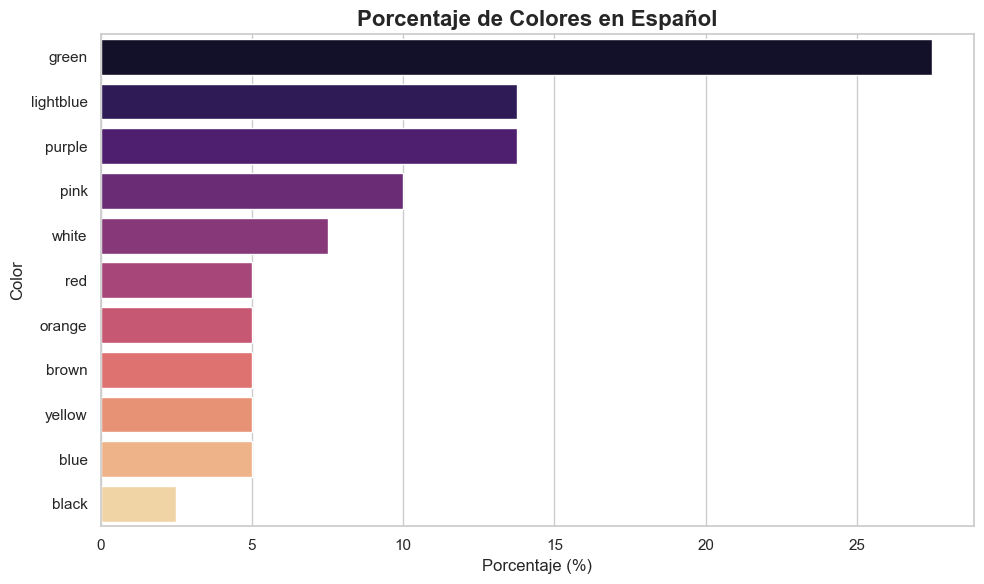

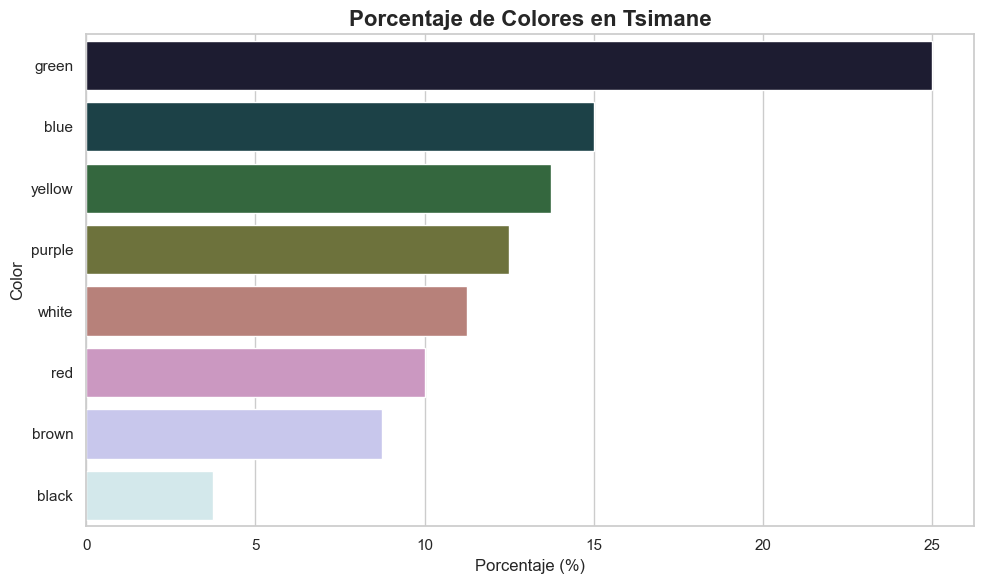

In [2]:
def plot_percentage(column, title, color_palette):
    # Calcular los porcentajes
    counts = df[column].value_counts(normalize=True) * 100
    
    # Crear el gráfico
    plt.figure(figsize=(10, 6))
    sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette=color_palette, legend=False)
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Porcentaje (%)', fontsize=12)
    plt.ylabel('Color', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_percentage('english_color', 'Porcentaje de Colores en Inglés', 'viridis')
plot_percentage('spanish_color', 'Porcentaje de Colores en Español', 'magma')
plot_percentage('tsimane_color', 'Porcentaje de Colores en Tsimane', 'cubehelix')

## 2. Correlación de Colores entre Idiomas

In [3]:
def get_freq_df(column):
    return df[column].value_counts(normalize=True).to_frame(name=f'pct_{column}') * 100

# Obtener frecuencias por idioma
freq_eng = get_freq_df('english_color')
freq_spa = get_freq_df('spanish_color')
freq_tsi = get_freq_df('tsimane_color')

def plot_correlation(df1, df2, col1, col2, title):
    # Unir dataframes para alinear colores
    corr_df = pd.merge(df1, df2, left_index=True, right_index=True, how='outer').fillna(0)
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=corr_df, x=f'pct_{col1}', y=f'pct_{col2}', s=100)
    
    # Añadir etiquetas a cada punto
    for color, row in corr_df.iterrows():
        plt.annotate(color, (row[f'pct_{col1}'], row[f'pct_{col2}']), 
                     textcoords="offset points", xytext=(5,5), ha='left')
    
    # Añadir línea de referencia (correlación perfecta)
    max_val = max(corr_df.max())
    plt.plot([0, max_val], [0, max_val], '--', color='gray', alpha=0.5)
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(f'Porcentaje en {col1.split("_")[0].capitalize()} (%)', fontsize=12)
    plt.ylabel(f'Porcentaje en {col2.split("_")[0].capitalize()} (%)', fontsize=12)
    plt.tight_layout()
    plt.show()

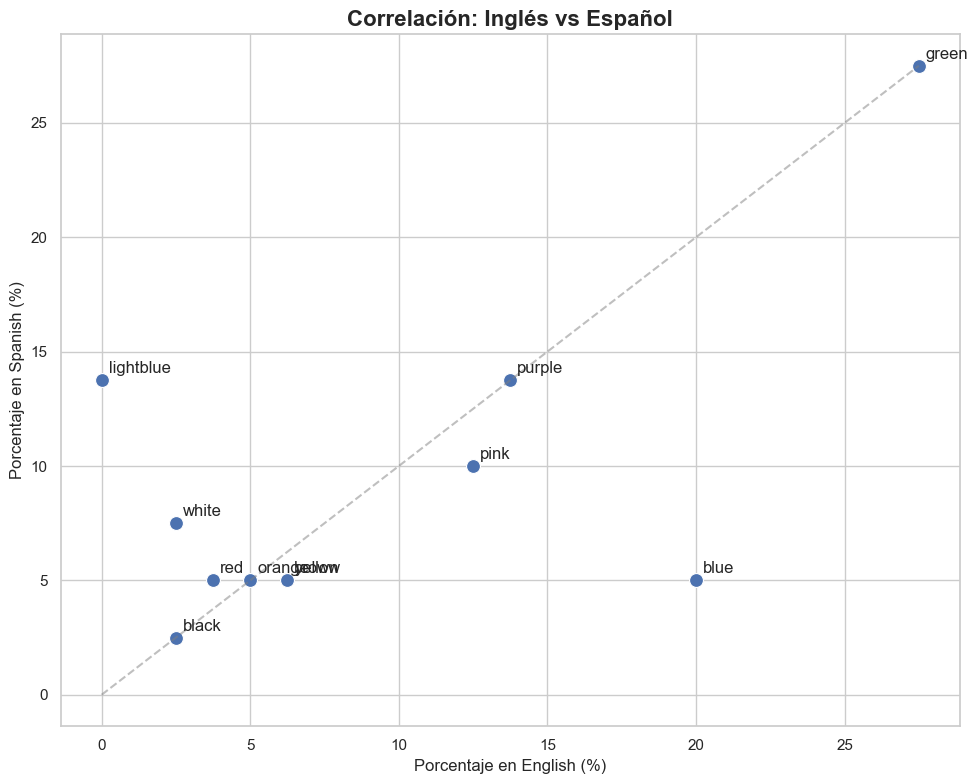

In [4]:
plot_correlation(freq_eng, freq_spa, 'english_color', 'spanish_color', 'Correlación: Inglés vs Español')

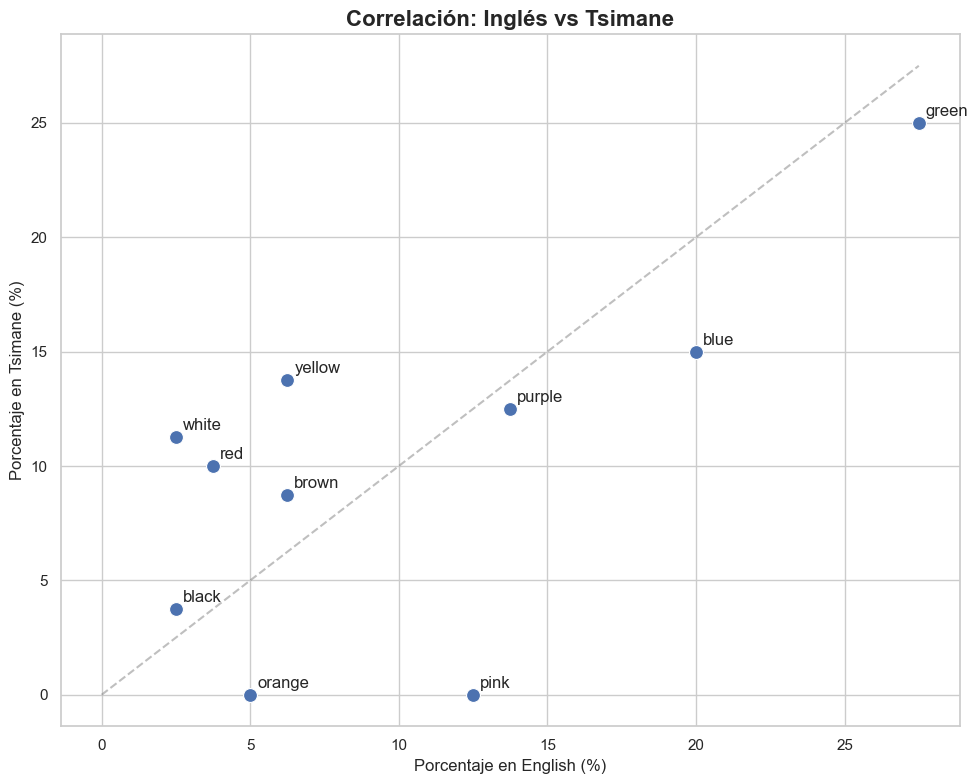

In [5]:
plot_correlation(freq_eng, freq_tsi, 'english_color', 'tsimane_color', 'Correlación: Inglés vs Tsimane')

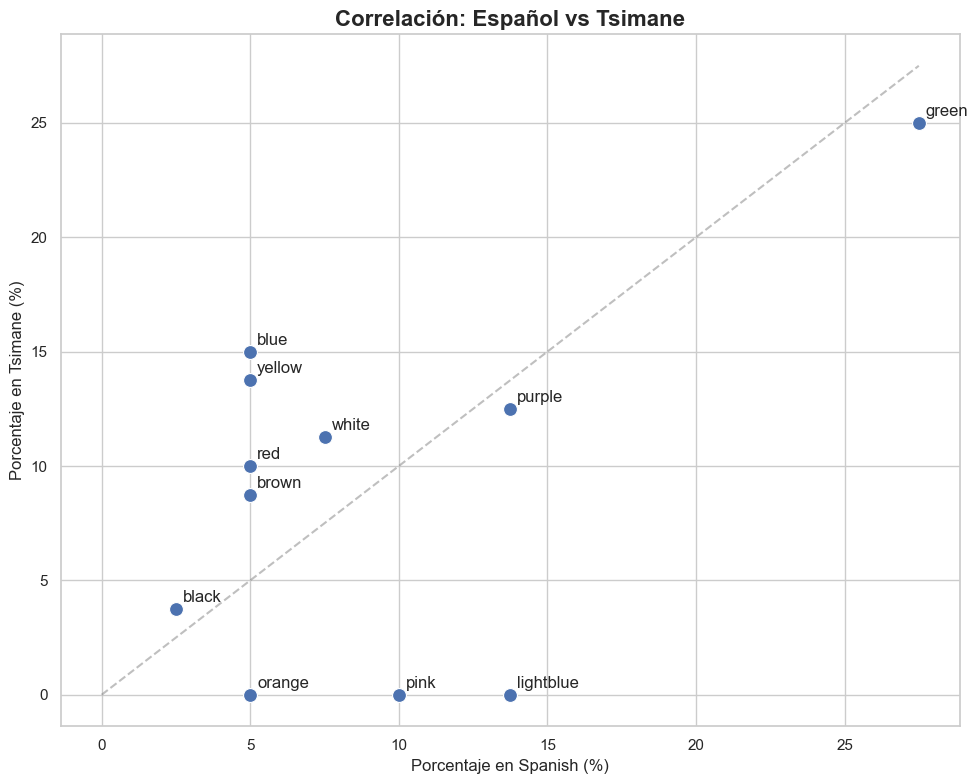

In [6]:
plot_correlation(freq_spa, freq_tsi, 'spanish_color', 'tsimane_color', 'Correlación: Español vs Tsimane')